In [ ]:
# --- Imports ---
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

from src.splits import stratified_split, stratified_kfold
from src.experiments import run_cross_validation_sweep, run_scaling_experiment

In [ ]:
# --- Build Dev Set ---
# Re-load data and re-create splits using the same seed
# so results match previous notebook exactly.

df = pd.read_csv("../data/titanic_cleaned.csv")

X = df.drop(columns=["survived"]).values
y = df["survived"].values

X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X,
    y,
    train_frac=0.6,
    val_frac=0.2,
    test_frac=0.2,
    seed=42
)

# combine train + val → dev set
X_dev = np.vstack((X_train, X_val))
y_dev = np.concatenate((y_train, y_val))

print(f"Dev set shape: X={X_dev.shape}, y={y_dev.shape}")
print(f"Positive rate: {y_dev.mean():.4f}")


Dev set shape:             X=(1048, 10), y=(1048,)
Dev set positive rate:     0.3817


In [ ]:
# --- Check Stratified K-Fold ---
folds = stratified_kfold(X_dev, y_dev, n_splits=5, random_state=42)

print(f"Overall positive rate: {y_dev.mean():.4f}\n")

for i, (X_tr, y_tr, X_val, y_val) in enumerate(folds):
    print(f"Fold {i+1}")
    print(f"  Train: {y_tr.mean():.4f} (n={len(y_tr)})")
    print(f"  Val:   {y_val.mean():.4f} (n={len(y_val)})")

Total dev positive rate: 0.3817

Fold 1:
  Train positive rate: 0.3819  (n=838)
  Val   positive rate: 0.3810  (n=210)
Fold 2:
  Train positive rate: 0.3819  (n=838)
  Val   positive rate: 0.3810  (n=210)
Fold 3:
  Train positive rate: 0.3819  (n=838)
  Val   positive rate: 0.3810  (n=210)
Fold 4:
  Train positive rate: 0.3814  (n=839)
  Val   positive rate: 0.3828  (n=209)
Fold 5:
  Train positive rate: 0.3814  (n=839)
  Val   positive rate: 0.3828  (n=209)


Running 5-fold cross-validation sweep over k...


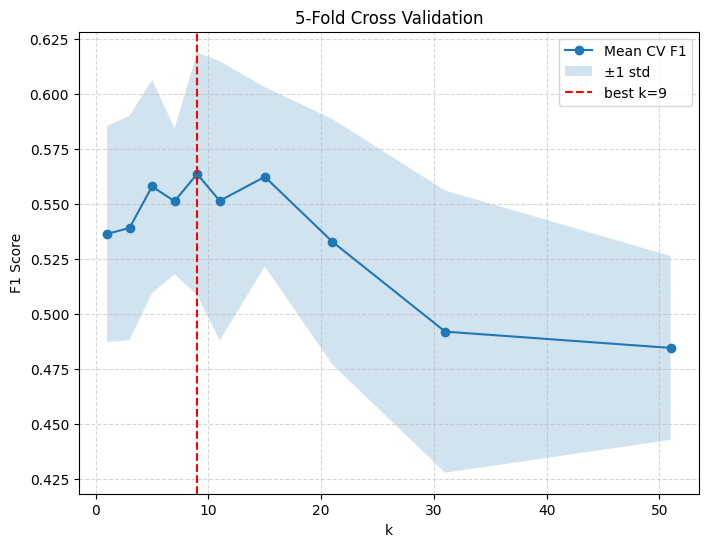


Best k by mean CV F1: k = 9  (mean F1 = 0.5637)


In [ ]:
# --- Cross-Validation Sweep ---
print("Running 5-fold CV over different k values...")

best_cv_k, best_cv_f1 = run_cross_validation_sweep(
    X_dev,
    y_dev,
    n_splits=5
)

print(f"\nBest k (CV F1): {best_cv_k} | Mean F1: {best_cv_f1:.4f}")

In [ ]:
# --- Scaling Experiment ---
print(f"Running scaling test with k={best_cv_k}...")

scaled_cv_f1 = run_scaling_experiment(
    X_dev,
    y_dev,
    best_cv_k,
    n_splits=5
)

print("-" * 40)
print(f"Unscaled CV F1: {best_cv_f1:.4f}")
print(f"Scaled CV F1:   {scaled_cv_f1:.4f}")
print(f"Difference:      {scaled_cv_f1 - best_cv_f1:+.4f}")

Running scaling experiment with best_cv_k = 9...
----------------------------------------
Unscaled mean CV F1: 0.5637
Scaled   mean CV F1: 0.7125
Lift:                +0.1488
----------------------------------------
